,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


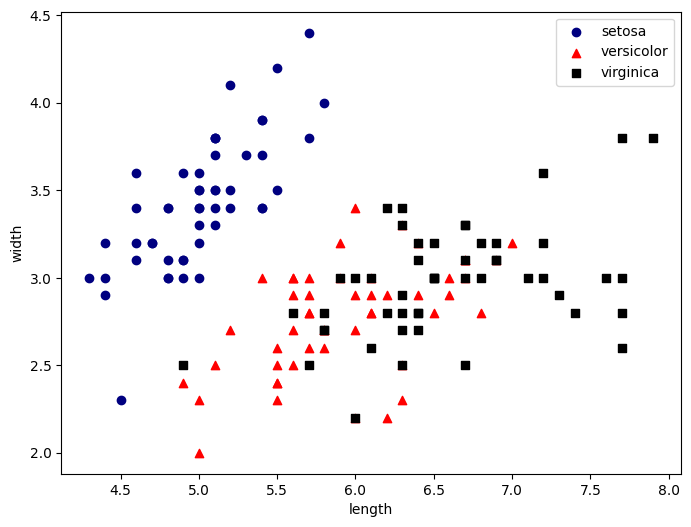

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from IPython.display import display

# 아이리스 데이터
iris = datasets.load_iris()
x = iris.data
y = iris.target
target_nm = iris.target_names

df_iris = pd.DataFrame(x, columns=iris.feature_names)  #엑셀표로
df_iris['target'] = y   #target 열에 꽃종류 번호 추가
display(df_iris.head())
#꽃받침 길이와 너비 산점도
plt.figure(figsize=(8,6))
markers=['o','^','s']  #꽃종류마다 다른점모양
for i, (color, marker) in enumerate(zip(['navy', 'red', 'black'], markers)):
    plt.scatter(x[y == i, 0], x[y == i, 1], marker=marker, color=color, label=target_nm[i])
# y == i -> i번 꽃만 골라냄, x[:,0] 꽃밫침길이, x[:,1] → 꽃받침 너비
plt.xlabel('length')  #축이름
plt.ylabel('width')
plt.legend()
plt.show()  #그래츠풀력

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9666666666666667, 1.0, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667]


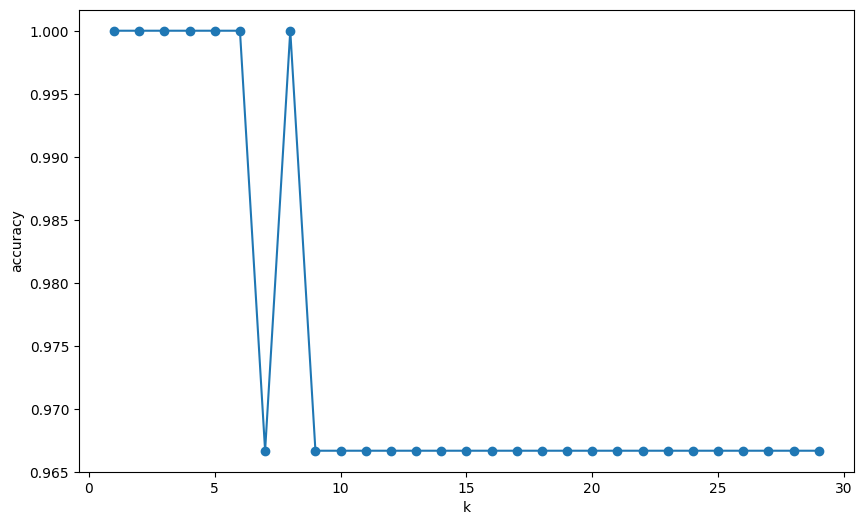

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier #knn 분류모델
import numpy as np
np.random.seed(1) #난수결과동일하게 고정
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
scores = []
#k를 1-29 까지
for n in range(1,30):
    knn.n_neighbors = n
    score = knn.score(x_test, y_test)
    scores.append(score)
print(scores)
plt.figure(figsize=(10,6))
plt.plot(range(1,30), scores, marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()

In [10]:
new_flower = [[5.0, 3.5,1.5, 0.2]]
pred = knn.predict(new_flower)
print(f'예측 : { pred[0]} 품종 : {target_nm[pred[0]]}')

예측 : 0 품종 : setosa
